# 04 — Customer Segmentation
K-Means clustering on RFM features + segment profiling.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
%matplotlib inline


## 2. Load features

In [2]:
df = pd.read_parquet("../data/processed/features.parquet")
print(f"Shape: {df.shape}")
df.head()


Shape: (4290, 20)


,CustomerID,Recency,Frequency,Monetary,Log_Monetary,Log_Frequency,AOV,SpendStd,PreferredDayOfWeek,WeekendRatio,PreferredHour,UniqueSKUs,TotalItems,RepeatSKURatio,AvgGap,StdGap,ReturnRate,CohortMonth,ActiveMonths,DaysSinceFirstPurchase
0,12347,2,7,4060.40,8.309283,2.079442,580.057143,351.455168,1,0.000000,14,102,2218,0.436464,60.333333,18.478817,0.000000,2010-12,7,365
1,12348,75,4,1186.68,7.079757,1.609438,296.670000,225.294269,3,0.095238,19,15,1468,0.285714,94.000000,70.149840,0.000000,2010-12,4,282
2,12349,19,1,1353.80,7.211409,0.693147,1353.800000,0.000000,0,0.000000,9,70,625,0.000000,0.000000,0.000000,0.000000,2011-11,1,0
3,12350,310,1,294.40,5.688330,0.693147,294.400000,0.000000,2,0.000000,16,16,196,0.000000,0.000000,0.000000,0.000000,2011-02,1,0
4,12352,36,7,1385.74,7.234711,2.079442,197.962857,81.916277,1,0.000000,14,57,526,0.259740,43.000000,68.419296,0.909091,2011-02,4,260


## 3. Prepare RFM matrix

In [3]:
rfm_cols = ["Recency", "Log_Frequency", "Log_Monetary"]
X_raw = df[rfm_cols].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
print("Scaled shape:", X_scaled.shape)


Scaled shape: (4290, 3)


## 4. Elbow method — find optimal K

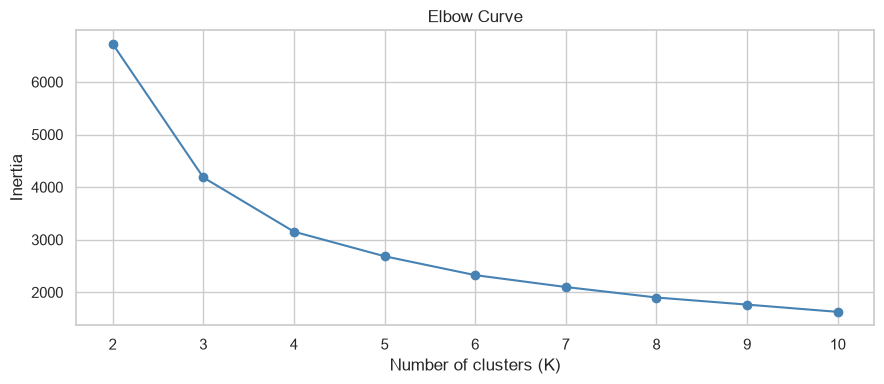

In [4]:
inertias = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(9, 4))
plt.plot(K_range, inertias, marker="o", color="steelblue")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Curve")
plt.xticks(K_range)
plt.tight_layout()
plt.show()


## 5. Silhouette scores

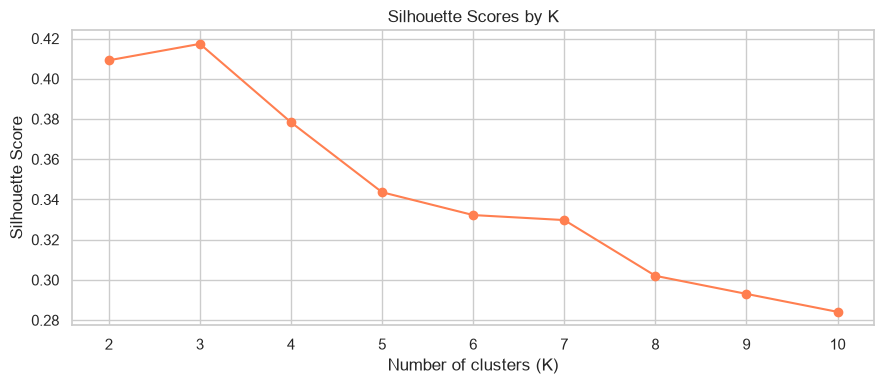

Best K by silhouette: 3


In [5]:
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(9, 4))
plt.plot(K_range, sil_scores, marker="o", color="coral")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores by K")
plt.xticks(K_range)
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f"Best K by silhouette: {best_k}")


## 6. Fit final model

In [6]:
K = 4   # adjust based on elbow + silhouette above

km = KMeans(n_clusters=K, random_state=42, n_init=10)
df["Segment"] = km.fit_predict(X_scaled)

print("Segment distribution:")
print(df["Segment"].value_counts().sort_index())


Segment distribution:
Segment
0    1327
1    1424
2     615
3     924
Name: count, dtype: int64


## 7. Segment profiles

In [7]:
profile = df.groupby("Segment")[["Recency","Frequency","Monetary","AOV"]].mean().round(2)
profile["Count"] = df.groupby("Segment").size()
profile["RevenueShare"] = (
    df.groupby("Segment")["Monetary"].sum() / df["Monetary"].sum() * 100
).round(1)
profile


,Recency,Frequency,Monetary,AOV,Count,RevenueShare
Segment,,,,,,
0,59.27,1.48,350.13,266.80,1327,6.7
1,46.57,4.00,1410.13,413.69,1424,29.1
2,19.38,14.74,6668.52,451.88,615,59.5
3,260.03,1.35,349.21,270.16,924,4.7


## 8. Label segments

In [8]:
# Adjust labels based on your actual profile output above
segment_labels = {
    0: "Champions",
    1: "At Risk",
    2: "Loyal Customers",
    3: "Lost / Inactive",
}
df["SegmentLabel"] = df["Segment"].map(segment_labels)
df["SegmentLabel"].value_counts()


SegmentLabel
At Risk            1424
Champions          1327
Lost / Inactive     924
Loyal Customers     615
Name: count, dtype: int64

## 9. PCA scatter — 2D visualisation

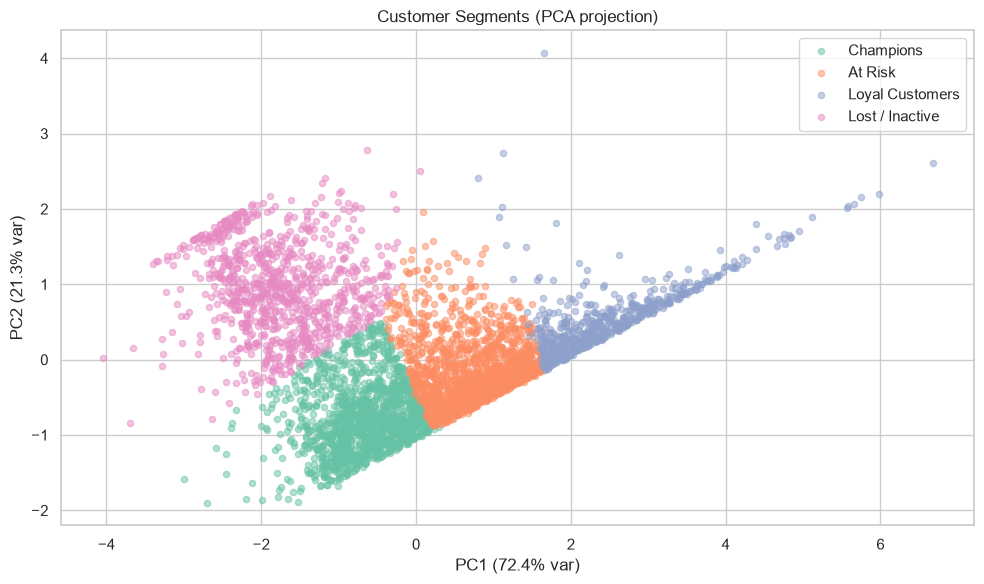

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
palette = sns.color_palette("Set2", K)
for seg in range(K):
    mask = df["Segment"] == seg
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                label=segment_labels.get(seg, str(seg)),
                alpha=0.5, s=20, color=palette[seg])

plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.title("Customer Segments (PCA projection)")
plt.legend()
plt.tight_layout()
plt.show()


## 10. RFM box plots per segment

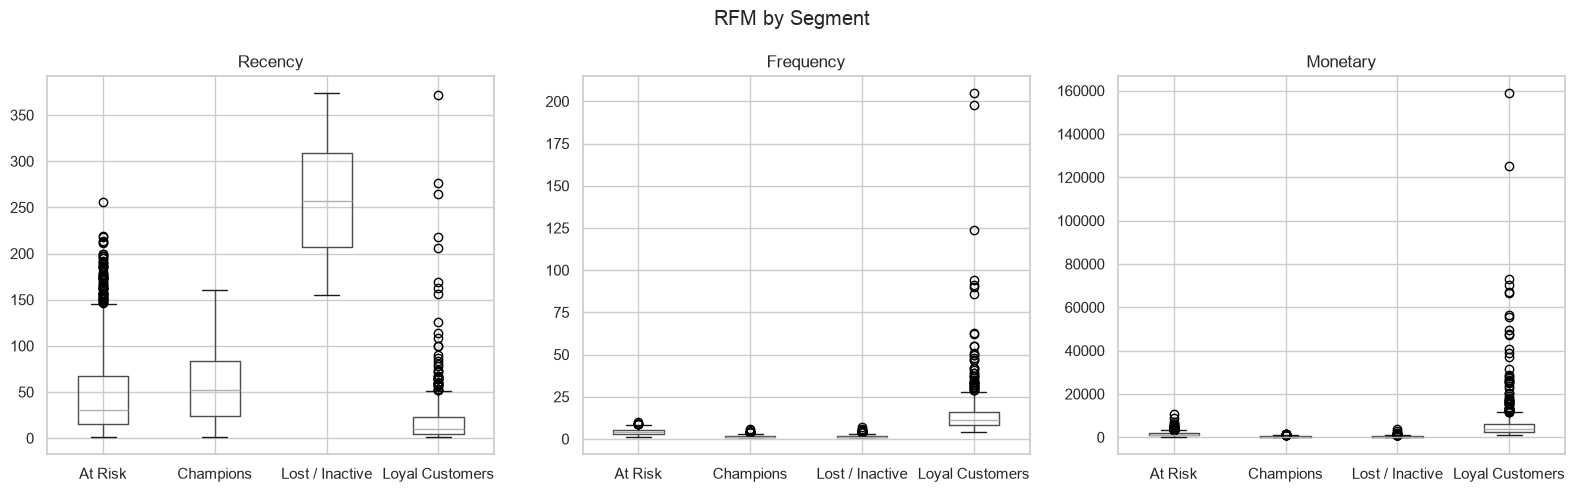

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ["Recency","Frequency","Monetary"]):
    df.boxplot(column=col, by="SegmentLabel", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("RFM by Segment")
plt.tight_layout()
plt.show()


## 11. Save segmented features

In [11]:
df.to_parquet("../data/processed/features_segmented.parquet", index=False)
print("Saved → data/processed/features_segmented.parquet")


Saved → data/processed/features_segmented.parquet


## 12. Save model artifact

In [12]:
import joblib
from pathlib import Path

Path("../models/artifacts").mkdir(parents=True, exist_ok=True)
joblib.dump(km,     "../models/artifacts/kmeans.joblib")
joblib.dump(scaler, "../models/artifacts/scaler_rfm.joblib")
print("Artifacts saved ✓")


Artifacts saved ✓
